In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau




In [ ]:
# Load and preprocess data
df = pd.read_csv('generated_new.csv')
df.dropna(inplace=True)

# Feature Engineering

# Extract minutes from Time (HH:MM)
df['Minutes'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour * 60 + \
                pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.minute

# Extract hour from Minutes
df['Hour'] = df['Minutes'] // 60

# Is weekend (binary: 1 for weekend, 0 for weekday)
df['Is_Weekend'] = (pd.to_datetime(df['Time'], format='%H:%M').dt.weekday >= 5).astype(int)

# Add interaction terms
df['Temp_Humidity'] = df['Temp'] * df['Humidity']
df['Light_Occupancy'] = df['Light_Intensity'] * df['Occupancy']
df['Temp_Light'] = df['Temp'] * df['Light_Intensity']
df['Temp_Occupancy'] = df['Temp'] * df['Occupancy']
df['Humidity_Light'] = df['Humidity'] * df['Light_Intensity']


In [ ]:

# Lag features (energy consumption, temperature, and humidity)
df['Energy_Lag1'] = df['Energy'].shift(1)
df['Temp_Lag1'] = df['Temp'].shift(1)
df['Humidity_Lag1'] = df['Humidity'].shift(1)
df['Light_Lag1'] = df['Light_Intensity'].shift(1)
df['Occupancy_Lag1'] = df['Occupancy'].shift(1)

# Additional Lag Features
df['Energy_Lag2'] = df['Energy'].shift(2)
df['Temp_Lag2'] = df['Temp'].shift(2)
df['Humidity_Lag2'] = df['Humidity'].shift(2)

# Rolling features (e.g., rolling mean for past 3 hours)
df['Temp_RollingMean3'] = df['Temp'].rolling(window=3).mean()
df['Humidity_RollingMean3'] = df['Humidity'].rolling(window=3).mean()
df['Light_RollingMean3'] = df['Light_Intensity'].rolling(window=3).mean()

# Remove the first few rows which have NaN after lagging and rolling
df.dropna(inplace=True)


In [ ]:

# One-hot encode Day of the week (categorical feature)
df = pd.get_dummies(df, columns=['Day'], drop_first=True)

# Define features and target
features = ['Minutes', 'Temp', 'Humidity', 'Light_Intensity', 'Occupancy', 'Temp_Humidity', 'Light_Occupancy',
            'Temp_Light', 'Temp_Occupancy', 'Humidity_Light', 'Is_Weekend', 'Energy_Lag1', 'Temp_Lag1', 'Humidity_Lag1',
            'Light_Lag1', 'Occupancy_Lag1', 'Energy_Lag2', 'Temp_Lag2', 'Humidity_Lag2',
            'Temp_RollingMean3', 'Humidity_RollingMean3', 'Light_RollingMean3'] + [col for col in df.columns if col.startswith('Day_')]

X = df[features].values
y = df['Energy'].values

# Scale data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Create sequences for LSTM
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 15  # Temporal dependency window
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)


In [ ]:
# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# Build the optimized with GRU
def build_optimized_model(input_shape):
    model = Sequential([
        Bidirectional(GRU(128, activation='tanh', return_sequences=True), input_shape=input_shape),
        Dropout(0.3),
        BatchNormalization(),
        GRU(64, activation='tanh', return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1)  # Output for energy prediction
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

model = build_optimized_model((seq_length, X_train.shape[2]))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Use early stopping and learning rate reduction on plateau
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, lr_reduction],
    verbose=1
)

# Predictions with Monte Carlo Dropout
def monte_carlo_predictions(model, X_test, num_samples=100):
    preds = np.array([model.predict(X_test, verbose=0) for _ in range(num_samples)])
    mean_pred = preds.mean(axis=0)
    uncertainty = preds.std(axis=0)
    return mean_pred, uncertainty


Epoch 1/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - loss: 0.0750 - mae: 0.1995 - val_loss: 0.0262 - val_mae: 0.1224 - learning_rate: 0.0010
Epoch 2/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - loss: 0.0150 - mae: 0.0958 - val_loss: 0.0070 - val_mae: 0.0629 - learning_rate: 0.0010
Epoch 3/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - loss: 0.0103 - mae: 0.0789 - val_loss: 0.0047 - val_mae: 0.0500 - learning_rate: 0.0010
Epoch 4/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - loss: 0.0092 - mae: 0.0747 - val_loss: 0.0078 - val_mae: 0.0751 - learning_rate: 0.0010
Epoch 5/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - loss: 0.0078 - mae: 0.0683 - val_loss: 0.0042 - val_mae: 0.0496 - learning_rate: 0.0010
Epoch 6/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - loss: 0.0073 - mae: 0.0658 - val_loss: 0.0055 - val_mae: 0.0621 - learning_rate: 0.0010
Epoch 7/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - loss: 0.0061 - mae: 0.0608 - val_loss: 0.0056 - val_mae: 0.0614 - learnin

In [ ]:
# Get predictions
mean_pred_scaled, uncertainty_scaled = monte_carlo_predictions(model, X_test)
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1))
mean_pred = scaler_y.inverse_transform(mean_pred_scaled)
uncertainty = scaler_y.inverse_transform(uncertainty_scaled)

# Evaluate metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, mean_pred))
mae = mean_absolute_error(y_test_actual, mean_pred)
r2 = r2_score(y_test_actual, mean_pred)
mape = np.mean(np.abs((y_test_actual - mean_pred) / y_test_actual)) * 100

print("\nModel Performance:")
print(f"Root Mean Square Error (RMSE): {rmse:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.3f} kWh")
print(f"R-squared Score: {r2:.3f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")



Model Performance:
Root Mean Square Error (RMSE): 0.250
Mean Absolute Error (MAE): 0.188 kWh
R-squared Score: 0.989
Mean Absolute Percentage Error (MAPE): 2.84%


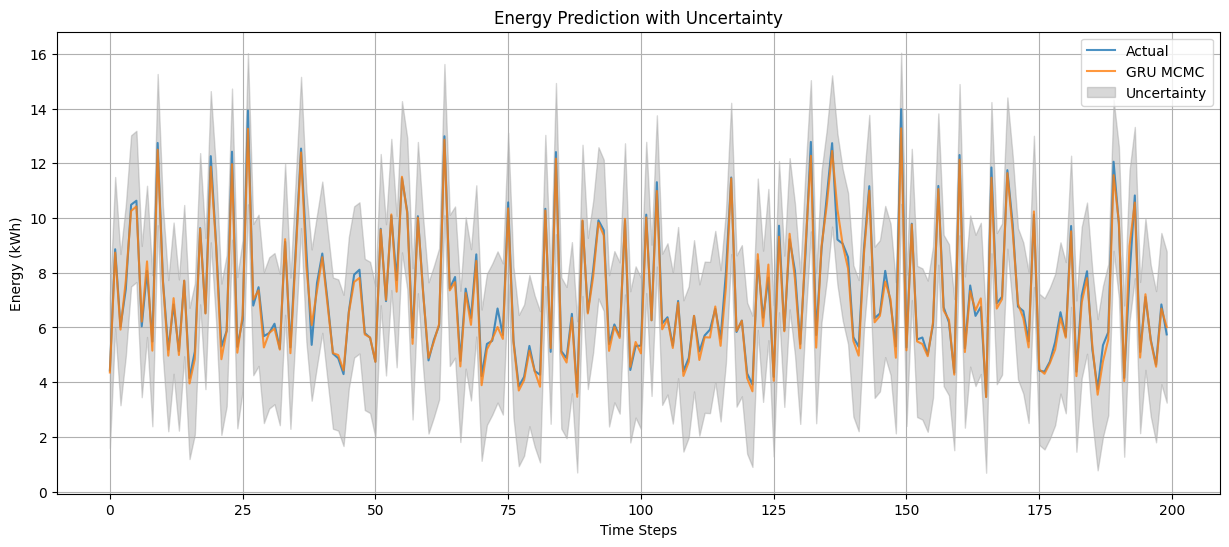

In [ ]:

# Plot predictions and uncertainty
def plot_predictions(y_test_actual, mean_pred, uncertainty, num_points=200):
    plt.figure(figsize=(15, 6))
    plt.plot(y_test_actual[:num_points], label='Actual', alpha=0.8)
    plt.plot(mean_pred[:num_points], label='GRU MCMC', alpha=0.8)
    plt.fill_between(
        np.arange(num_points),
        (mean_pred - uncertainty)[:num_points].flatten(),
        (mean_pred + uncertainty)[:num_points].flatten(),
        color='gray', alpha=0.3, label='Uncertainty'
    )
    plt.title('Energy Prediction with Uncertainty')
    plt.xlabel('Time Steps')
    plt.ylabel('Energy (kWh)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_predictions(y_test_actual, mean_pred, uncertainty)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
import tensorflow as tf

# Assuming the scaler and model are already trained and saved
scaler_X = MinMaxScaler()  # Replace with the scaler fitted on the training data
scaler_y = MinMaxScaler()  # Replace with the scaler fitted on the target variable

# Load the trained model (if saved previously)
model = load_model('energy_prediction_model.h5')  # Replace with your model file path

# Function to preprocess a single input and make predictions
def preprocess_single_input(input_data, scaler_X, scaler_y, seq_length):
    # Create a DataFrame from the input data
    input_df = pd.DataFrame([input_data], columns=['Minutes', 'Temp', 'Humidity', 'Light_Intensity', 'Occupancy',
                                                   'Temp_Humidity', 'Light_Occupancy', 'Temp_Light', 'Temp_Occupancy',
                                                   'Humidity_Light', 'Is_Weekend', 'Energy_Lag1', 'Temp_Lag1',
                                                   'Humidity_Lag1', 'Light_Lag1', 'Occupancy_Lag1'])

    # Scale the input data
    input_scaled = scaler_X.transform(input_df)

    # Create sequences for LSTM (using the same seq_length as the training model)
    def create_sequences(X, seq_length):
        X_seq = []
        for i in range(len(X) - seq_length):
            X_seq.append(X[i:i + seq_length])
        return np.array(X_seq)

    input_seq = create_sequences(input_scaled, seq_length)
    return input_seq

# Function to predict energy consumption based on input
def predict_energy_consumption(input_data, model, scaler_X, scaler_y, seq_length=15):
    # Preprocess the input data
    input_seq = preprocess_single_input(input_data, scaler_X, scaler_y, seq_length)

    # Make predictions using the trained model
    prediction_scaled = model.predict(input_seq, verbose=0)

    # Inverse scale the prediction to get original energy consumption
    prediction = scaler_y.inverse_transform(prediction_scaled)
    return prediction

# Example of using the function to predict energy consumption
# You can enter new data here as a list or array
new_input_data = [60, 22.5, 55, 150, 1, 22.5 * 55, 150 * 1, 22.5 * 150, 22.5 * 1, 55 * 150, 0, 15.5, 22, 55, 120, 1]  # Example input data

# Call the function with the input data
predicted_energy = predict_energy_consumption(new_input_data, model, scaler_X, scaler_y)

# Print the prediction
print(f"Predicted Energy Consumption: {predicted_energy[0][0]:.3f} kWh")
